# The Imagination Machine III
## Prediction and Representational Closure in Quasi-Periodic Environments

This notebook implements the quasi-periodic prediction experiment from Imagination Machines III (Tracy, 2026).

An agent with no access to raw phase angles observes only relational phase differences between three rationally independent cyclic variables. Trained solely to minimize next-observation prediction error through a compressive bottleneck, the agent is evaluated on whether its converged h1→h2 weight matrix linearly encodes the Koopman eigenvalue structure of its environment — the rotation amounts the linear prediction head must extract to propagate phase observations forward in time.

The experiment constitutes an existence proof of TIM III's central claim: prediction error alone, passed through a compressive bottleneck with an observation LayerNorm, is sufficient to drive linear encoding of the complete independent Koopman spectrum — both e^{i·d_span} and e^{i·d_least} — in the h1→h2 weight matrix. Generalization is evaluated via k-fold cross-validation over the full environment pool, with each agent trained independently from identical initial weights.

**Notebook structure:**
- Cell 0 — this note
- Cell 1 — imports, configuration, master seed
- Cell 2 — environment generation (Dirichlet(2,2,6) sampling, trajectory functions)
- Cell 3 — observation model: h(θ) → (cos Δᵢⱼ, sin Δᵢⱼ)
- Cell 4 — agent architecture (residual MLP, obs LayerNorm, state LayerNorm, linear head)
- Cell 5 — vmap infrastructure (functional forward pass, manual Adam)
- Cell 6 — learning rate search
- Cell 7 — parallel training loop (multi-GPU, ThreadPoolExecutor)
- Cell 8 — save / load dataset
- Cell 9 — normalize weight vectors (StandardScaler)
- Cell 10 — filter near-degenerate environments (optional)
- Cell 11 — linear probe: 4-part target (span + least), k-fold CV
- Cell 12 — metric decomposition: MSE / RMSE / Var / R²
- Cell 13 — visualization: 4-part probe results

Global note: numerical dimensions mentioned in comments are illustrative only; actual values may vary

In [1]:
# ============================================================
# Cell 1 | Installation (SCC)
# ============================================================
#
# Installs PyTorch to the project directory only if not already
# available. Run once; subsequent runs skip the install.
# ============================================================

import sys, subprocess

install_dir = ""

if install_dir not in sys.path:
    sys.path.insert(0, install_dir)

try:
    import torch
    print(f"PyTorch {torch.__version__} already available -- skipping install.")
except ImportError:
    print("PyTorch not found -- installing...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "--target", install_dir,
        "--upgrade",
        "torch",
    ])
    print(f"Installation complete -> {install_dir}")
    print("Restart the kernel, then run from Cell 2.")

PyTorch 2.12.0+cu130 already available -- skipping install.


In [2]:
# ============================================================
# Cell 1 | Imports, Configuration, and Master Seed
# ============================================================
#
# All imports and hyperparameters live here. Sub-seeds are
# derived deterministically from MASTER_SEED so each component
# (env sampling, weight init, training) is independently
# reproducible but jointly controlled.
#
# Probe evaluation uses k-fold cross-validation over the full
# environment pool — no fixed train/test split is needed.
# N_ENVS controls the total number of independently trained
# agents; the probe folds are defined post-hoc in Cell 11/13.
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, List
import os
import sys
sys.path.insert(0, "")

print(f"PyTorch version : {torch.__version__}")

# --- Multi-GPU setup ---
if torch.cuda.device_count() > 1:
    DEVICES = [torch.device(f"cuda:{i}") for i in range(torch.cuda.device_count())]
    print(f"Using {len(DEVICES)} GPUs: {DEVICES}")
else:
    DEVICES = [torch.device("cuda" if torch.cuda.is_available() else "cpu")]
    print(f"Using single device: {DEVICES[0]}")
DEVICE = DEVICES[0]

# --- Reproducibility ---
MASTER_SEED    = 76
LOAD_FROM_DISK = True   # set True to skip Cell 7

# --- Environment ---
N_ENVS         = 5000
T_STEPS        = 2000
ALPHA_1        = 1.0
ALPHA_2        = 1.0
ALPHA_3        = 1.0

# --- Agent architecture ---
OBS_DIM        = 6
STATE_DIM      = 32
MLP_HIDDEN_DIM = 32
MLP_N_LAYERS   = 2

# --- Training ---
N_EPOCHS_PER_ENV = 200
LEARNING_RATE    = 7e-3
VMAP_CHUNK_SIZE  = 50
USE_OBS_NORM     = True

# --- Linear probe ---
PROBE_K_FOLDS  = 5

# --- Derive sub-seeds ---
rng           = np.random.default_rng(MASTER_SEED)
SEED_ENV      = int(rng.integers(0, 2**31))
SEED_WEIGHTS  = int(rng.integers(0, 2**31))
SEED_TRAINING = int(rng.integers(0, 2**31))

print("Sub-seeds derived from master seed:")
print(f"  SEED_ENV      : {SEED_ENV}")
print(f"  SEED_WEIGHTS  : {SEED_WEIGHTS}")
print(f"  SEED_TRAINING : {SEED_TRAINING}")
print()
print(f"N_ENVS            : {N_ENVS}")
print(f"T_STEPS           : {T_STEPS}")
print(f"MLP_HIDDEN_DIM    : {MLP_HIDDEN_DIM}  →  PARAM_DIM = {MLP_HIDDEN_DIM**2 + MLP_HIDDEN_DIM}")
print(f"N_EPOCHS_PER_ENV  : {N_EPOCHS_PER_ENV}")
print(f"PROBE_K_FOLDS     : {PROBE_K_FOLDS}")

PyTorch version : 2.12.0+cu130
Using 4 GPUs: [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]
Sub-seeds derived from master seed:
  SEED_ENV      : 1214976684
  SEED_WEIGHTS  : 1731583730
  SEED_TRAINING : 1012311645

N_ENVS            : 5000
T_STEPS           : 2000
MLP_HIDDEN_DIM    : 32  →  PARAM_DIM = 1056
N_EPOCHS_PER_ENV  : 200
PROBE_K_FOLDS     : 5


In [3]:
# ============================================================
# Cell 2 | Environment Generation
# ============================================================
#
# Each environment is a frequency vector ω sampled from the
# interior of the normalized simplex Δ²:
#   Δ² = { ω ∈ ℝ³ : ωᵢ > 0, ω₁+ω₂+ω₃ = 1 }
#
# Sampling via Dirichlet(2,2,6) — asymmetric, concentrating
# mass toward (1/5, 1/5, 3/5) and giving the span channel
# meaningful dynamic range.
#
# A single pool of N_ENVS environments is sampled — no
# train/test split. The probe evaluates generalization via
# k-fold cross-validation in Cell 11.
#
# omegas are raw and unsorted — this is what the agents train
# on. Probe targets are constructed from raw omegas in Cell 11,
# which sorts internally as needed.
# ============================================================

def sample_frequency_vectors(
    n:    int,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return np.sort(rng.dirichlet([ALPHA_1, ALPHA_2, ALPHA_3], size=n).astype(np.float64), axis = 1)

# def sample_frequency_vectors(n: int, seed: int) -> np.ndarray:
#     """
#     Sample n frequency vectors uniformly from the largest circle
#     inscribed in the 2-simplex { ω ∈ ℝ³ : ωᵢ > 0, Σωᵢ = 1 }.

#     The inscribed circle has center c = (1/3, 1/3, 1/3) and
#     radius r = 1/√6 in the plane of the simplex. This is the
#     unique rotationally symmetric distribution on the simplex
#     that avoids corner degeneracy (one oscillator dominates)
#     and centroid concentration (all gaps near zero).

#     Two orthonormal basis vectors spanning the simplex plane:
#         e1 = (1, -1, 0) / √2
#         e2 = (1,  1, -2) / √6

#     A point in the disk is:
#         ω = c + ρ·cos(θ)·e1 + ρ·sin(θ)·e2
#     where ρ ~ √Uniform[0, r²] and θ ~ Uniform[0, 2π).

#     Parameters
#     ----------
#     n    : int — number of environments
#     seed : int — random seed

#     Returns
#     -------
#     omegas : np.ndarray (n, 3), each row sums to 1, all entries > 0
#     """
#     rng = np.random.default_rng(seed)

#     # Inscribed circle radius and center
#     r = 1.0 / np.sqrt(6.0)
#     c = np.array([1/3, 1/3, 1/3])

#     # Orthonormal basis for the simplex plane
#     e1 = np.array([ 1.0, -1.0,  0.0]) / np.sqrt(2.0)
#     e2 = np.array([ 1.0,  1.0, -2.0]) / np.sqrt(6.0)

#     # Sample uniformly from disk via area-preserving polar coords
#     # ρ = r * √u ensures uniform area distribution
#     u     = rng.uniform(0.0, 1.0, size=n)
#     theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
#     rho   = r * np.sqrt(u)

#     # Map to simplex
#     omegas = (c[np.newaxis, :]
#               + rho[:, np.newaxis] * np.cos(theta)[:, np.newaxis] * e1[np.newaxis, :]
#               + rho[:, np.newaxis] * np.sin(theta)[:, np.newaxis] * e2[np.newaxis, :])

#     # Sanity checks
#     assert np.allclose(omegas.sum(axis=1), 1.0, atol=1e-10), \
#         "Rows do not sum to 1"
#     assert (omegas > 0).all(), \
#         "Some frequencies are non-positive — inscribed circle exceeds simplex boundary"

#     return omegas.astype(np.float64)


def make_trajectory(
    omega: np.ndarray,
    T:     int,
    seed:  int,
) -> np.ndarray:
    rng      = np.random.default_rng(seed)
    theta    = np.zeros((T + 1, 3))
    theta[0] = rng.uniform(0.0, 2.0 * np.pi, size=3)
    step     = 2.0 * np.pi * omega
    for t in range(T):
        theta[t + 1] = (theta[t] + step) % (2.0 * np.pi)
    return theta


# Sample full environment pool — raw, unsorted
omegas = sample_frequency_vectors(N_ENVS, SEED_ENV)

print(f"Sampling method : Dirichlet({ALPHA_1},{ALPHA_2},{ALPHA_3})")
print(f"Environments    : {omegas.shape}")
print(f"Sample ω[0]     : {omegas[0].round(4)}  sum={omegas[0].sum():.6f}")
print(f"Mean ω          : {omegas.mean(axis=0).round(4)}")
print(f"Std  ω          : {omegas.std(axis=0).round(4)}")
print(f"Min  ω          : {omegas.min(axis=0).round(4)}")
print(f"Max  ω          : {omegas.max(axis=0).round(4)}")

Sampling method : Dirichlet(1.0,1.0,1.0)
Environments    : (5000, 3)
Sample ω[0]     : [0.0213 0.2041 0.7746]  sum=1.000000
Mean ω          : [0.1125 0.2789 0.6086]
Std  ω          : [0.079  0.104  0.1433]
Min  ω          : [0.     0.0118 0.3348]
Max  ω          : [0.3326 0.4983 0.9836]


In [4]:
# ============================================================
# Cell 3 | Observation Model
# ============================================================
#
# The agent observes only relational phase differences —
# not raw angles. For three oscillators there are three
# pairs: (1,2), (1,3), (2,3). Each pair contributes
# (cos Δᵢⱼ, sin Δᵢⱼ), the real and imaginary parts of
# the Koopman eigenfunction zᵢⱼ = e^{iΔᵢⱼ} ∈ ℂ,
# giving a 6-dimensional real observation vector.
#
# This is the bridge from ℂ (theory) to ℝ (MLP input).
# ============================================================

def observe(
    theta: np.ndarray,
) -> np.ndarray:
    """
    Compute relational phase-difference observations from raw angles.

    Parameters
    ----------
    theta : np.ndarray, shape (..., 3)
        Raw phase angles in [0, 2π).

    Returns
    -------
    obs : np.ndarray, shape (..., 6)
        (cos Δ₁₂, sin Δ₁₂, cos Δ₁₃, sin Δ₁₃, cos Δ₂₃, sin Δ₂₃)
        All values lie in [-1, 1].
    """
    d12 = theta[..., 0] - theta[..., 1]
    d13 = theta[..., 0] - theta[..., 2]
    d23 = theta[..., 1] - theta[..., 2]
    obs = np.stack([
        np.cos(d12), np.sin(d12),
        np.cos(d13), np.sin(d13),
        np.cos(d23), np.sin(d23),
    ], axis=-1)
    return obs.astype(np.float32)


# Sanity check
_theta_check = make_trajectory(omegas[0], T=5, seed=0)
_obs_check   = observe(_theta_check)
print(f"Trajectory shape     : {_theta_check.shape}")
print(f"Observation shape    : {_obs_check.shape}")
print(f"obs[0]               : {_obs_check[0].round(4)}")
print(f"All values in [-1,1] : {bool(np.all(np.abs(_obs_check) <= 1.0 + 1e-6))}")

Trajectory shape     : (6, 3)
Observation shape    : (6, 6)
obs[0]               : [-0.6715  0.741  -0.8236 -0.5672  0.1327  0.9912]
All values in [-1,1] : True


In [5]:
# ============================================================
# Cell 4 | Agent Architecture
# ============================================================
#
# Two components:
#
#   1. MLP state-update with residual connection and LayerNorm:
#        sₜ₊₁ = LayerNorm(sₜ + f([sₜ, o̊ₜ]))
#      Input:  STATE_DIM + OBS_DIM
#      Hidden: MLP_HIDDEN_DIM  (two layers)
#      Output: STATE_DIM
#
#      Layer structure:
#        Linear(STATE_DIM + OBS_DIM → MLP_HIDDEN_DIM)  — perception
#        ReLU
#        Linear(MLP_HIDDEN_DIM → MLP_HIDDEN_DIM)        — bottleneck
#        ReLU
#        Linear(MLP_HIDDEN_DIM → STATE_DIM)             — expand
#
#      The MLP output is added to the current state (residual,
#      faithful to TIM IV's delta formulation), then normalized
#      via LayerNorm to prevent unbounded state accumulation
#      over the trajectory.
#
#   2. Linear prediction head:  ôₜ₊₁ = g([sₜ₊₁, o̊ₜ])
#      Input:  STATE_DIM + OBS_DIM
#      Output: OBS_DIM
#
#   3. Observation LayerNorm (learned): o̊ₜ = LayerNorm(oₜ)
#      Learned affine parameters γ, β ∈ ℝ⁶ calibrate the
#      perceptual space jointly with the prediction task.
#
# CANONICAL __init__ ORDER:
#   obs_norm → state_update → prediction_head → state_norm
#
# The full converged parameter vector is saved after training.
# Downstream probe cells draw random same-size slices from the
# full vector to test for distributed Koopman encoding.
# ============================================================


class QuasiPeriodicAgent(nn.Module):
    """
    Predictive agent with two-layer MLP state update, residual
    connection, LayerNorm state stabilization, learned observation
    LayerNorm, and a linear prediction head — faithful to TIM IV.

    Parameters
    ----------
    obs_dim      : dimension of relational observation
    state_dim    : dimension of internal state
    hidden_dim   : dimension of both hidden layers
    use_obs_norm : if True, apply learned LayerNorm to observation
    """

    def __init__(
        self,
        obs_dim:      int  = OBS_DIM,
        state_dim:    int  = STATE_DIM,
        hidden_dim:   int  = MLP_HIDDEN_DIM,
        use_obs_norm: bool = USE_OBS_NORM,
    ) -> None:
        super().__init__()
        self.obs_dim      = obs_dim
        self.state_dim    = state_dim
        self.use_obs_norm = use_obs_norm

        self.obs_norm = nn.LayerNorm(obs_dim) if use_obs_norm else nn.Identity()

        self.state_update = nn.Sequential(
            nn.Linear(state_dim + obs_dim, hidden_dim),  # layer 0: perception
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),            # layer 2: bottleneck
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim),             # layer 4: expand
        )

        self.prediction_head = nn.Linear(state_dim + obs_dim, obs_dim)
        self.state_norm      = nn.LayerNorm(state_dim)

    def forward(
        self,
        s: torch.Tensor,
        o: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        One step of the agent.

        Parameters
        ----------
        s : (batch, state_dim)  current internal state
        o : (batch, obs_dim)    current observation (raw)

        Returns
        -------
        s_next : (batch, state_dim)  updated state
        o_pred : (batch, obs_dim)    predicted next observation
        """
        o_normed = self.obs_norm(o)
        s_next   = self.state_norm(
            s + self.state_update(torch.cat([s, o_normed], dim=-1))
        )
        o_pred   = self.prediction_head(torch.cat([s_next, o_normed], dim=-1))
        return s_next, o_pred

    def init_state(
        self,
        batch_size: int,
        device:     torch.device,
    ) -> torch.Tensor:
        return torch.zeros(batch_size, self.state_dim, device=device)


# Instantiate
torch.manual_seed(SEED_WEIGHTS)
agent = QuasiPeriodicAgent(
    obs_dim      = OBS_DIM,
    state_dim    = STATE_DIM,
    hidden_dim   = MLP_HIDDEN_DIM,
    use_obs_norm = USE_OBS_NORM,
).to(DEVICE)

n_params = sum(p.numel() for p in agent.parameters() if p.requires_grad)

print(agent)
print(f"\nTotal trainable parameters : {n_params}")
print(f"Observation LayerNorm      : {USE_OBS_NORM} (learned)")
print(f"Prediction head            : linear (unconstrained)")

QuasiPeriodicAgent(
  (obs_norm): LayerNorm((6,), eps=1e-05, elementwise_affine=True, bias=True)
  (state_update): Sequential(
    (0): Linear(in_features=38, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
  )
  (prediction_head): Linear(in_features=38, out_features=6, bias=True)
  (state_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
)

Total trainable parameters : 3670
Observation LayerNorm      : True (learned)
Prediction head            : linear (unconstrained)


In [6]:
# ============================================================
# Cell 5 | Functional Forward Pass and vmap Infrastructure
# ============================================================
#
# Multi-GPU compatible. Module and s_init created per-device
# via make_functional_loss(device).
#
# Loss formulation:
#   s, o_pred = agent(s, o_t)
#   loss      = MSE(o_pred, obs[t+1])
#
# Raw next observation as target. The obs space is geometrically
# clean (cos/sin, bounded in [-1,1]) and does not require
# normalization as a target. The agent's internal learned
# obs_norm calibrates its perception of the current input.
#
# The full converged parameter vector is saved after training.
# Downstream probe cells draw random same-size slices from the
# full vector to test for distributed Koopman encoding.
# ============================================================

from torch.func import functional_call, vmap, grad


# --- Parameter shape registry ---
_ref_agent   = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
PARAM_SHAPES = {
    name: p.shape
    for name, p in _ref_agent.named_parameters()
}
PARAM_SLICES = {}
offset = 0
for name, shape in PARAM_SHAPES.items():
    numel = int(np.prod(shape))
    PARAM_SLICES[name] = (offset, offset + numel)
    offset += numel
TOTAL_PARAM_DIM = offset
del _ref_agent

print(f"Total agent parameters : {TOTAL_PARAM_DIM}")
print(f"Parameter names        : {list(PARAM_SHAPES.keys())}")


def vector_to_params(vec: torch.Tensor) -> dict:
    """Reconstruct parameter dict from flat 1D tensor."""
    return {
        name: vec[start:end].reshape(PARAM_SHAPES[name])
        for name, (start, end) in PARAM_SLICES.items()
    }


def params_to_vector(params: dict) -> torch.Tensor:
    """Flatten parameter dict to 1D tensor."""
    return torch.cat([p.flatten() for p in params.values()])


def get_module(device: torch.device) -> QuasiPeriodicAgent:
    """Return a reference module on the given device."""
    return QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM).to(device)


def make_functional_loss(device: torch.device):
    """
    Returns functional_loss, batched_loss, batched_grad
    closed over a module on the given device.
    Called once per chunk.

    Loss: MSE(o_pred, obs[t+1])
    Raw next observation as target.
    forward() returns (s_next, o_pred) — 2 values.
    """
    module = get_module(device)
    s_init = torch.zeros(1, STATE_DIM, device=device)

    def functional_loss(
        vec: torch.Tensor,
        obs: torch.Tensor,
    ) -> torch.Tensor:
        params = vector_to_params(vec)
        s      = s_init
        total  = torch.tensor(0.0, device=device)

        for t in range(T_STEPS):
            s, o_pred = functional_call(
                module, params, (s, obs[t].unsqueeze(0))
            )
            total = total + nn.functional.mse_loss(
                o_pred, obs[t + 1].unsqueeze(0)
            )

        return total / T_STEPS

    batched_loss = vmap(functional_loss, in_dims=(0, 0))
    batched_grad = vmap(grad(functional_loss), in_dims=(0, 0))

    return functional_loss, batched_loss, batched_grad


def init_param_batch(B: int, device: torch.device) -> torch.Tensor:
    """Initialize B identical parameter vectors from SEED_WEIGHTS."""
    torch.manual_seed(SEED_WEIGHTS)
    ref = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
    vec = params_to_vector(dict(ref.named_parameters()))
    return vec.unsqueeze(0).expand(B, -1).clone().to(device)


def adam_init(B: int, device: torch.device) -> dict:
    """Initialize Adam state for B agents."""
    return {
        "m": torch.zeros(B, TOTAL_PARAM_DIM, device=device),
        "v": torch.zeros(B, TOTAL_PARAM_DIM, device=device),
        "t": 0,
    }


def adam_step(
    vecs:  torch.Tensor,
    grads: torch.Tensor,
    state: dict,
    lr:    float,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps:   float = 1e-8,
) -> Tuple[torch.Tensor, dict]:
    """One Adam update for B agents."""
    state["t"] += 1
    t        = state["t"]
    state["m"] = beta1 * state["m"] + (1 - beta1) * grads
    state["v"] = beta2 * state["v"] + (1 - beta2) * grads ** 2
    m_hat    = state["m"] / (1 - beta1 ** t)
    v_hat    = state["v"] / (1 - beta2 ** t)
    return vecs - lr * m_hat / (v_hat.sqrt() + eps), state


def clip_grads(
    grads:    torch.Tensor,
    max_norm: float = 1.0,
) -> torch.Tensor:
    """Clip gradients per agent by global norm."""
    norms = grads.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    scale = (max_norm / norms).clamp(max=1.0)
    return grads * scale


def make_obs_batch(
    omegas:    np.ndarray,
    T:         int,
    base_seed: int,
    device:    torch.device,
) -> torch.Tensor:
    """
    Generate a batch of raw observation sequences on device.
    No pre-normalization — obs_norm applied inside agent forward.
    """
    B      = omegas.shape[0]
    thetas = np.stack([
        make_trajectory(omegas[b], T, seed=base_seed + b)
        for b in range(B)
    ])
    obs = observe(thetas)   # (B, T+1, 6)
    return torch.tensor(obs, dtype=torch.float32, device=device)


print("\nvmap infrastructure ready.")
print(f"  TOTAL_PARAM_DIM : {TOTAL_PARAM_DIM}  (full agent parameter vector)")

Total agent parameters : 3670
Parameter names        : ['obs_norm.weight', 'obs_norm.bias', 'state_update.0.weight', 'state_update.0.bias', 'state_update.2.weight', 'state_update.2.bias', 'state_update.4.weight', 'state_update.4.bias', 'prediction_head.weight', 'prediction_head.bias', 'state_norm.weight', 'state_norm.bias']

vmap infrastructure ready.
  TOTAL_PARAM_DIM : 3670  (full agent parameter vector)


In [7]:
# ============================================================
# Cell 6 | Learning Rate Search (vmap, Multi-GPU)
# ============================================================
#
# Tests each learning rate candidate by training
# LR_SEARCH_N_ENVS agents in parallel via vmap on a subset
# of environments. Uses make_functional_loss(device) for
# device-local batched_grad and batched_loss functions.
#
# If any agent produces NaN or inf in parameters or losses,
# that candidate is immediately disqualified.
#
# The best valid candidate is set as LEARNING_RATE.
# ============================================================

LR_CANDIDATES    = [9e-3, 8e-3, 7e-3, 6e-3, 5e-3, 4e-3]
LR_SEARCH_EPOCHS = 300
LR_SEARCH_N_ENVS = min(200, VMAP_CHUNK_SIZE)

if not LOAD_FROM_DISK:
    omegas_search = omegas[:LR_SEARCH_N_ENVS]

    print(f"Learning rate search: {LR_SEARCH_EPOCHS} epochs, "
          f"{LR_SEARCH_N_ENVS} parallel agents per candidate\n")
    print(f"{'LR':<12}  {'Mean Final Loss':>16}  {'Status':>14}")
    print("-" * 46)

    lr_results = {}

    for lr in LR_CANDIDATES:
        device = DEVICES[0]

        _, batched_loss, batched_grad = make_functional_loss(device)

        vecs         = init_param_batch(LR_SEARCH_N_ENVS, device)
        opt          = adam_init(LR_SEARCH_N_ENVS, device)
        disqualified = False
        final_losses = None

        for epoch in range(LR_SEARCH_EPOCHS):
            obs = make_obs_batch(
                omegas_search, T_STEPS,
                base_seed = SEED_TRAINING + epoch * LR_SEARCH_N_ENVS,
                device    = device,
            )

            grads = batched_grad(vecs, obs)
            grads = clip_grads(grads, max_norm=1.0)
            vecs, opt = adam_step(vecs, grads, opt, lr=lr)

            if not torch.isfinite(vecs).all():
                disqualified = True
                break

            if epoch == LR_SEARCH_EPOCHS - 1:
                with torch.no_grad():
                    losses       = batched_loss(vecs, obs)
                    final_losses = losses.detach().cpu().tolist()
                if not all(np.isfinite(l) for l in final_losses):
                    disqualified = True

            print(
                f"\r  lr={lr:.0e}  epoch {epoch+1:>3}/{LR_SEARCH_EPOCHS}",
                end="", flush=True,
            )

        if disqualified:
            lr_results[lr] = float("nan")
            print(f"\n{lr:<12.0e}  {'disqualified':>16}  {'NaN/inf':>14}")
        else:
            mean_loss = float(np.mean(final_losses))
            lr_results[lr] = mean_loss
            print(f"\n{lr:<12.0e}  {mean_loss:>16.6f}  {'ok':>14}")

    valid_results = {lr: loss for lr, loss in lr_results.items()
                     if np.isfinite(loss)}

    if not valid_results:
        print("\nAll candidates disqualified — add smaller LR candidates.")
    else:
        best_lr = min(valid_results, key=valid_results.get)
        print(f"\nAll results   : {lr_results}")
        print(f"Valid results : {valid_results}")
        LEARNING_RATE = best_lr
        print(f"\nLEARNING_RATE set to: {LEARNING_RATE:.0e}  "
              f"(loss={valid_results[LEARNING_RATE]:.6f})")

In [8]:
# ============================================================
# Cell 7 | Parallel Training Loop (Multi-GPU + vmap)
# ============================================================
#
# Chunks are distributed across available GPUs in round-robin.
# ThreadPoolExecutor runs len(DEVICES) chunks simultaneously.
# Progress prints every 10 epochs per chunk.
#
# The full parameter vector is retained per agent:
#   full_params : (N_ENVS, TOTAL_PARAM_DIM)
#
# Slicing for the h1→h2 probe and any random control probes
# is done downstream in Cell 11, after loading from disk.
# Probe generalization is evaluated via k-fold CV in Cell 11.
# ============================================================

import time
from concurrent.futures import ThreadPoolExecutor
import threading

print_lock = threading.Lock()
N_DEVICES  = len(DEVICES)


def print_chunk_progress(
    chunk_idx: int,
    epoch:     int,
    n_chunks:  int,
    device:    torch.device,
    mean_loss: float = None,
) -> None:
    if (epoch + 1) % 10 != 0 and epoch != N_EPOCHS_PER_ENV - 1:
        return
    loss_str = f"  loss: {mean_loss:.6f}" if mean_loss is not None else ""
    with print_lock:
        print(
            f"chunk {chunk_idx+1:>3}/{n_chunks}  "
            f"epoch {epoch+1:>3}/{N_EPOCHS_PER_ENV}  "
            f"device: {device}{loss_str}"
        )


def train_chunk(
    omegas:    np.ndarray,
    base_seed: int,
    chunk_idx: int,
    n_chunks:  int,
    device:    torch.device,
) -> Tuple[int, np.ndarray, List[float]]:
    """
    Train one chunk of agents in parallel via vmap on device.

    Returns
    -------
    chunk_idx       : int
    full_param_vecs : np.ndarray (B, TOTAL_PARAM_DIM)
    final_losses    : List[float]
    """
    B = omegas.shape[0]

    _, batched_loss, batched_grad = make_functional_loss(device)

    vecs = init_param_batch(B, device)
    opt  = adam_init(B, device)

    final_losses = None

    for epoch in range(N_EPOCHS_PER_ENV):
        obs = make_obs_batch(
            omegas, T_STEPS,
            base_seed = base_seed + epoch * B,
            device    = device,
        )

        grads = batched_grad(vecs, obs)
        vecs, opt = adam_step(vecs, grads, opt, lr=LEARNING_RATE)

        if epoch == N_EPOCHS_PER_ENV - 1:
            with torch.no_grad():
                losses       = batched_loss(vecs, obs)
                final_losses = losses.detach().cpu().tolist()

        print_chunk_progress(
            chunk_idx, epoch, n_chunks, device,
            mean_loss = float(np.mean(final_losses)) if final_losses else None,
        )

    mean = float(np.mean(final_losses))
    std  = float(np.std(final_losses))
    with print_lock:
        print(
            f"chunk {chunk_idx+1:>3}/{n_chunks}  complete  "
            f"mean: {mean:.6f}  std: {std:.6f}  device: {device}"
        )

    full_param_vecs = vecs.detach().cpu().numpy()
    return chunk_idx, full_param_vecs, final_losses


def collect_all_final_states(
    omegas:    np.ndarray,
    base_seed: int,
) -> Tuple[np.ndarray, List[float]]:
    """
    Returns
    -------
    full_params : np.ndarray (N, TOTAL_PARAM_DIM)
    all_losses  : List[float]
    """
    N                  = len(omegas)
    n_chunks           = int(np.ceil(N / VMAP_CHUNK_SIZE))
    full_params        = np.zeros((N, TOTAL_PARAM_DIM), dtype=np.float32)
    chunk_losses_store = [None] * n_chunks

    def process_chunk(c):
        start        = c * VMAP_CHUNK_SIZE
        end          = min(start + VMAP_CHUNK_SIZE, N)
        chunk_device = DEVICES[c % len(DEVICES)]
        return train_chunk(
            omegas[start:end],
            base_seed = base_seed + start * (N_EPOCHS_PER_ENV + 1),
            chunk_idx = c,
            n_chunks  = n_chunks,
            device    = chunk_device,
        )

    with ThreadPoolExecutor(max_workers=N_DEVICES) as executor:
        futures = [executor.submit(process_chunk, c) for c in range(n_chunks)]
        for future in futures:
            c, chunk_full, chunk_losses = future.result()
            start                  = c * VMAP_CHUNK_SIZE
            end                    = min(start + VMAP_CHUNK_SIZE, N)
            full_params[start:end] = chunk_full
            chunk_losses_store[c]  = chunk_losses

    all_losses = [l for chunk in chunk_losses_store for l in chunk]

    print(
        f"\nAll chunks complete — {N} agents  "
        f"mean final loss: {float(np.mean(all_losses)):.6f}  "
        f"std: {float(np.std(all_losses)):.6f}\n"
    )
    return full_params, all_losses


if not LOAD_FROM_DISK:
    print("Training independent agents in parallel across GPUs...\n")

    _train_start = time.time()

    full_params, agent_losses = collect_all_final_states(
        omegas, base_seed=SEED_TRAINING,
    )

    _train_elapsed = time.time() - _train_start
    n_chunks       = int(np.ceil(N_ENVS / VMAP_CHUNK_SIZE))

    print(f"Full params   : {full_params.shape}")
    print(f"\nWall time     : {_train_elapsed/60:.1f} min  ({_train_elapsed:.1f} s)")
    print(f"Per-agent     : {_train_elapsed/N_ENVS*1000:.1f} ms")
    print(f"Per-chunk     : {_train_elapsed/n_chunks:.1f} s")

Training independent agents in parallel across GPUs...

chunk   4/100  epoch  10/200  device: cuda:3
chunk   2/100  epoch  10/200  device: cuda:1
chunk   3/100  epoch  10/200  device: cuda:2
chunk   1/100  epoch  10/200  device: cuda:0
chunk   4/100  epoch  20/200  device: cuda:3
chunk   2/100  epoch  20/200  device: cuda:1
chunk   3/100  epoch  20/200  device: cuda:2
chunk   1/100  epoch  20/200  device: cuda:0
chunk   4/100  epoch  30/200  device: cuda:3
chunk   3/100  epoch  30/200  device: cuda:2
chunk   1/100  epoch  30/200  device: cuda:0
chunk   2/100  epoch  30/200  device: cuda:1
chunk   3/100  epoch  40/200  device: cuda:2
chunk   4/100  epoch  40/200  device: cuda:3
chunk   1/100  epoch  40/200  device: cuda:0
chunk   2/100  epoch  40/200  device: cuda:1
chunk   3/100  epoch  50/200  device: cuda:2
chunk   1/100  epoch  50/200  device: cuda:0
chunk   4/100  epoch  50/200  device: cuda:3
chunk   2/100  epoch  50/200  device: cuda:1
chunk   3/100  epoch  60/200  device: cuda:2

In [9]:
# ============================================================
# Cell 8 | Save and Load Dataset
# ============================================================
#
# Saves full parameter vectors, frequency vectors, and agent
# losses to disk so Cell 7 only needs to run once.
#
# Probe targets (cos/sin Koopman eigenvalues) are NOT saved —
# they are cheap to recompute from omegas. Cell 11 always
# recomputes from omegas.
#
# To reload without retraining, set LOAD_FROM_DISK = True
# in Cell 1.
# ============================================================

import os

SAVE_DIR = (f"./data/"
            f"_a_{ALPHA_1}_{ALPHA_2}_{ALPHA_3}"
            f"_n_{N_ENVS}_s_{STATE_DIM}_h_{MLP_HIDDEN_DIM}"
            f"_t_{T_STEPS}_nep_{N_EPOCHS_PER_ENV}")
os.makedirs(SAVE_DIR, exist_ok=True)

if LOAD_FROM_DISK:
    full_params  = np.load(f"{SAVE_DIR}/full_params.npy")
    omegas       = np.load(f"{SAVE_DIR}/omegas.npy")
    agent_losses = np.load(f"{SAVE_DIR}/agent_losses.npy").tolist()
    print("Loaded from disk:")
else:
    np.save(f"{SAVE_DIR}/full_params.npy",  full_params)
    np.save(f"{SAVE_DIR}/omegas.npy",        omegas)
    np.save(f"{SAVE_DIR}/agent_losses.npy",  np.array(agent_losses))
    print("Saved to disk:")

print(f"  full_params  : {full_params.shape}")
print(f"  omegas       : {omegas.shape}")
print(f"  agent_losses : {len(agent_losses)} values")
print(f"\nSAVE_DIR: {SAVE_DIR}")

Saved to disk:
  full_params  : (5000, 3670)
  omegas       : (5000, 3)
  agent_losses : 5000 values

SAVE_DIR: ./data/_a_1.0_1.0_1.0_n_5000_s_32_h_32_t_2000_nep_200


In [13]:
# ============================================================
# Cell 11 | Linear Probe: Random Slice Koopman Recovery
# ============================================================
#
# Runs P linear probes, each on a randomly drawn same-size
# slice of the full converged parameter vector. Reports the
# distribution of Joint R² values and mean alpha curve across
# slices.
#
# The finding that random same-size slices linearly encode the
# Koopman spectrum indicates that the encoding is distributed
# across the full parameter vector rather than localized to
# any specific layer.
# ============================================================

from sklearn.linear_model    import Ridge
from sklearn.metrics         import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing   import StandardScaler

TARGET_NAMES = [
    "cos(tau * d_mid)", "sin(tau * d_mid)",
    "cos(tau * d_least)", "sin(tau * d_least)",
]

N_RANDOM_SLICES   = 20
PARAM_DIM = TOTAL_PARAM_DIM // 5
RANDOM_PROBE_SEED = MASTER_SEED + 99
RIDGE_ALPHAS      = np.logspace(-3, 5, 33)


def koopman_targets_4(omegas: np.ndarray) -> np.ndarray:
    d12      = abs(omegas[:, 1] - omegas[:, 0])
    d23      = abs(omegas[:, 2] - omegas[:, 1])
    d13      = abs(omegas[:, 2] - omegas[:, 0])
    d_sorted = np.sort(np.stack([d12, d23, d13], axis=1), axis=1)
    d_least  = d_sorted[:, 0]
    d_mid    = d_sorted[:, 1]
    tau      = 2 * np.pi
    return np.stack([
        np.cos(tau * d_mid),   np.sin(tau * d_mid),
        np.cos(tau * d_least), np.sin(tau * d_least),
    ], axis=1).astype(np.float32)


def run_probe(
    features: np.ndarray,
    targets:  np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Run k-fold Ridge probe on features → targets.

    Returns
    -------
    mean_r2_curve : (len(RIDGE_ALPHAS),)
    std_r2_curve  : (len(RIDGE_ALPHAS),)
    best_alpha    : float
    joint_r2      : float
    """
    kf           = KFold(n_splits=PROBE_K_FOLDS, shuffle=True,
                         random_state=MASTER_SEED)
    fold_test_r2 = np.zeros((len(RIDGE_ALPHAS), PROBE_K_FOLDS))

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(features)):
        X_tr, X_te = features[train_idx], features[test_idx]
        y_tr, y_te = targets[train_idx],  targets[test_idx]
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)
        for ai, alpha in enumerate(RIDGE_ALPHAS):
            m = Ridge(alpha=alpha, fit_intercept=True)
            m.fit(X_tr, y_tr)
            fold_test_r2[ai, fold_idx] = r2_score(y_te, m.predict(X_te))

    mean_r2_curve = fold_test_r2.mean(axis=1)
    std_r2_curve  = fold_test_r2.std(axis=1)
    best_idx      = int(np.argmax(mean_r2_curve))
    best_alpha    = RIDGE_ALPHAS[best_idx]
    joint_r2      = mean_r2_curve[best_idx]

    return mean_r2_curve, std_r2_curve, best_alpha, joint_r2


# --- Recompute targets ---
targets = koopman_targets_4(omegas)

print(f"Probe targets : {targets.shape}")
for i, name in enumerate(TARGET_NAMES):
    col = targets[:, i]
    print(f"  {name:<14} range [{col.min():+.4f}, {col.max():+.4f}]  "
          f"mean={col.mean():+.4f}  std={col.std():.4f}")

# --- Run P random slice probes ---
print(f"\nRunning {N_RANDOM_SLICES} random slice probes "
      f"(slice size={PARAM_DIM} from {TOTAL_PARAM_DIM} total)...\n")

rng_rand = np.random.default_rng(RANDOM_PROBE_SEED)

random_all_mean_r2_curves = np.zeros((N_RANDOM_SLICES, len(RIDGE_ALPHAS)))
random_all_std_r2_curves  = np.zeros((N_RANDOM_SLICES, len(RIDGE_ALPHAS)))
random_all_joint_r2       = np.zeros(N_RANDOM_SLICES)
random_all_best_alphas    = np.zeros(N_RANDOM_SLICES)

for p in range(N_RANDOM_SLICES):
    rand_slice    = np.sort(
        rng_rand.choice(TOTAL_PARAM_DIM, size=PARAM_DIM, replace=False)
    )
    rand_features = full_params[:, rand_slice]

    mean_curve, std_curve, best_alpha_p, joint_r2_p = run_probe(
        rand_features, targets
    )

    random_all_mean_r2_curves[p] = mean_curve
    random_all_std_r2_curves[p]  = std_curve
    random_all_joint_r2[p]       = joint_r2_p
    random_all_best_alphas[p]    = best_alpha_p

    print(f"  slice {p+1:>2}/{N_RANDOM_SLICES}  "
          f"Joint R²={joint_r2_p:.3f}  best α={best_alpha_p:.2f}")

# --- Aggregate ---
random_mean_r2_curve = random_all_mean_r2_curves.mean(axis=0)
random_std_r2_curve  = random_all_mean_r2_curves.std(axis=0)
random_joint_r2_mean = random_all_joint_r2.mean()
random_joint_r2_std  = random_all_joint_r2.std()

print(f"\nSummary ({N_RANDOM_SLICES} random slices, "
      f"size {PARAM_DIM} from {TOTAL_PARAM_DIM}):")
print(f"  Mean Joint R² : {random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
print(f"  Min / Max     : {random_all_joint_r2.min():.3f} / "
      f"{random_all_joint_r2.max():.3f}")
print(f"  Mean best α   : {random_all_best_alphas.mean():.2f}")

Probe targets : (5000, 4)
  cos(tau * d_mid) range [-1.0000, +0.9999]  mean=-0.2585  std=0.5854
  sin(tau * d_mid) range [-1.0000, +1.0000]  mean=+0.3969  std=0.6580
  cos(tau * d_least) range [-0.4648, +1.0000]  mean=+0.6866  std=0.3394
  sin(tau * d_least) range [+0.0001, +1.0000]  mean=+0.5585  std=0.3187

Running 20 random slice probes (slice size=734 from 3670 total)...

  slice  1/20  Joint R²=0.966  best α=177.83
  slice  2/20  Joint R²=0.967  best α=177.83
  slice  3/20  Joint R²=0.964  best α=316.23
  slice  4/20  Joint R²=0.963  best α=177.83
  slice  5/20  Joint R²=0.967  best α=316.23
  slice  6/20  Joint R²=0.966  best α=177.83
  slice  7/20  Joint R²=0.973  best α=177.83
  slice  8/20  Joint R²=0.969  best α=177.83
  slice  9/20  Joint R²=0.965  best α=177.83
  slice 10/20  Joint R²=0.969  best α=177.83
  slice 11/20  Joint R²=0.968  best α=177.83
  slice 12/20  Joint R²=0.971  best α=177.83
  slice 13/20  Joint R²=0.964  best α=316.23
  slice 14/20  Joint R²=0.968  best 

In [14]:
# ============================================================
# Cell 12 | Metric Decomposition: MSE / RMSE / Var / R²
# ============================================================
#
# Reports per-channel decomposition at the mean best alpha
# across random slices, using the first random slice's
# out-of-fold predictions as a representative example.
# ============================================================

def _decompose(true, pred):
    mse  = np.mean((pred - true) ** 2, axis=0)
    var  = np.var(true, axis=0)
    rmse = np.sqrt(mse)
    r2   = 1.0 - mse / var
    return mse, rmse, var, r2


# Re-run probe on first random slice to get out-of-fold preds
rng_repr   = np.random.default_rng(RANDOM_PROBE_SEED)
repr_slice = np.sort(
    rng_repr.choice(TOTAL_PARAM_DIM, size=PARAM_DIM, replace=False)
)
repr_features = full_params[:, repr_slice]

kf          = KFold(n_splits=PROBE_K_FOLDS, shuffle=True,
                    random_state=MASTER_SEED)
probe_preds = np.zeros_like(targets)
best_alpha  = random_all_best_alphas[0]

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(repr_features)):
    X_tr, X_te = repr_features[train_idx], repr_features[test_idx]
    y_tr, y_te = targets[train_idx],       targets[test_idx]
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)
    m = Ridge(alpha=best_alpha, fit_intercept=True)
    m.fit(X_tr, y_tr)
    probe_preds[test_idx] = m.predict(X_te)

mse, rmse, var, r2 = _decompose(targets, probe_preds)
print(f"Per-channel decomposition — representative random slice "
      f"(R² = 1 − MSE/Var)\n")
print(f"{'Channel':<14} {'Var':>9} {'MSE':>10} {'RMSE':>9} {'R²':>8}")
print("─" * 54)
for i, name in enumerate(TARGET_NAMES):
    print(f"{name:<14} {var[i]:>9.5f} {mse[i]:>10.6f} "
          f"{rmse[i]:>9.4f} {r2[i]:>8.3f}")
print("─" * 54)
print(f"{'mean':<14} {var.mean():>9.5f} {mse.mean():>10.6f} "
      f"{rmse.mean():>9.4f} {r2.mean():>8.3f}")
print()
print("Read: low R² + small RMSE → target barely varies; encoding fine, little to recover.")
print("      low R² + large RMSE → genuine encoding failure.")

Per-channel decomposition — representative random slice (R² = 1 − MSE/Var)

Channel              Var        MSE      RMSE       R²
──────────────────────────────────────────────────────
cos(tau * d_mid)   0.34270   0.015633    0.1250    0.954
sin(tau * d_mid)   0.43294   0.008844    0.0940    0.980
cos(tau * d_least)   0.11517   0.004549    0.0674    0.961
sin(tau * d_least)   0.10156   0.002958    0.0544    0.971
──────────────────────────────────────────────────────
mean             0.24809   0.007996    0.0852    0.966

Read: low R² + small RMSE → target barely varies; encoding fine, little to recover.
      low R² + large RMSE → genuine encoding failure.


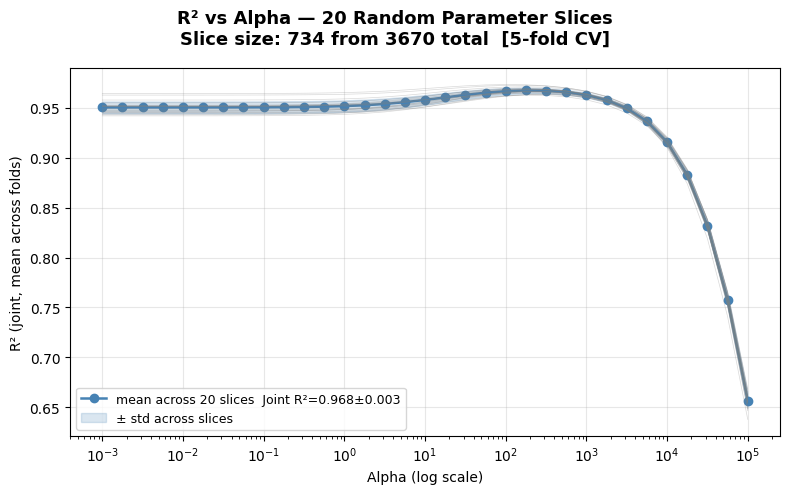

Figure 1 saved to tim_v_random_alpha__a_1.0_1.0_1.0_n_5000_s_32_h_32_t_2000_nep_200.png


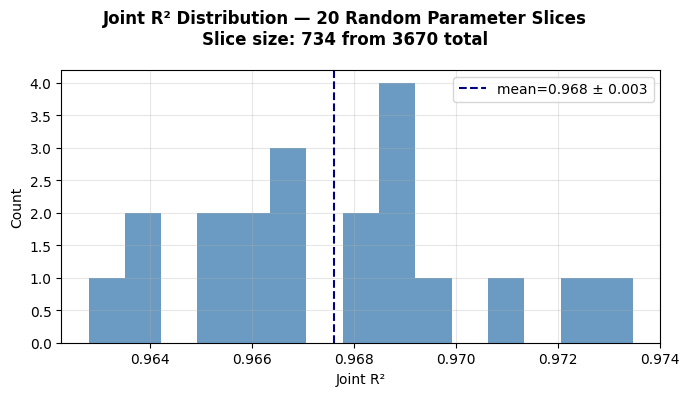

Figure 2 saved to tim_v_random_dist__a_1.0_1.0_1.0_n_5000_s_32_h_32_t_2000_nep_200.png

Random slice probe summary:
  N slices      : 20
  Slice size    : 734 / 3670 parameters
  Mean Joint R² : 0.968 ± 0.003
  Min / Max     : 0.963 / 0.973
  Mean best α   : 208.54


In [15]:
# ============================================================
# Cell 13 | Visualization — Random Slice Probe Results
# Two figures:
#   Fig 1: Mean alpha curve across P random slices with spread
#   Fig 2: Distribution of Joint R² values across P slices
# ============================================================

# ── Figure 1: mean alpha curve ────────────────────────────────
fig1, ax = plt.subplots(figsize=(8, 5))
fig1.suptitle(
    f"R² vs Alpha — {N_RANDOM_SLICES} Random Parameter Slices\n"
    f"Slice size: {PARAM_DIM} from {TOTAL_PARAM_DIM} total  "
    f"[{PROBE_K_FOLDS}-fold CV]",
    fontsize=13, fontweight="bold",
)

ax.semilogx(RIDGE_ALPHAS, random_mean_r2_curve,
            color="steelblue", linewidth=1.8, marker="o",
            label=f"mean across {N_RANDOM_SLICES} slices  "
                  f"Joint R²={random_joint_r2_mean:.3f}±{random_joint_r2_std:.3f}")
ax.fill_between(RIDGE_ALPHAS,
                random_mean_r2_curve - random_std_r2_curve,
                random_mean_r2_curve + random_std_r2_curve,
                color="steelblue", alpha=0.2, label="± std across slices")

# Individual slice curves in light grey for context
for p in range(N_RANDOM_SLICES):
    ax.semilogx(RIDGE_ALPHAS, random_all_mean_r2_curves[p],
                color="grey", linewidth=0.5, alpha=0.3)

ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("R² (joint, mean across folds)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig1.tight_layout()

fig1_name = f"tim_v_random_alpha_{SAVE_DIR.split('/')[-1]}.png"
fig1.savefig(fig1_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 1 saved to {fig1_name}")


# ── Figure 2: distribution of Joint R² ───────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.suptitle(
    f"Joint R² Distribution — {N_RANDOM_SLICES} Random Parameter Slices\n"
    f"Slice size: {PARAM_DIM} from {TOTAL_PARAM_DIM} total",
    fontsize=12, fontweight="bold",
)

ax2.hist(random_all_joint_r2, bins=min(N_RANDOM_SLICES, 15),
         color="steelblue", edgecolor="none", alpha=0.8)
ax2.axvline(random_joint_r2_mean, color="navy", linewidth=1.5,
            linestyle="--",
            label=f"mean={random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
ax2.set_xlabel("Joint R²")
ax2.set_ylabel("Count")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()

fig2_name = f"tim_v_random_dist_{SAVE_DIR.split('/')[-1]}.png"
fig2.savefig(fig2_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 2 saved to {fig2_name}")


# ── Summary ───────────────────────────────────────────────────
print(f"\nRandom slice probe summary:")
print(f"  N slices      : {N_RANDOM_SLICES}")
print(f"  Slice size    : {PARAM_DIM} / {TOTAL_PARAM_DIM} parameters")
print(f"  Mean Joint R² : {random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
print(f"  Min / Max     : {random_all_joint_r2.min():.3f} / "
      f"{random_all_joint_r2.max():.3f}")
print(f"  Mean best α   : {random_all_best_alphas.mean():.2f}")